# Swap Networks

Functionality for moving data between registers (swapping).

In [12]:
from qualtran import Bloq, CompositeBloq, BloqBuilder, Signature, Register
from qualtran import QBit, QInt, QUInt, QAny
from qualtran.drawing import show_bloq, show_call_graph, show_counts_sigma
from typing import *
import numpy as np
import sympy
import cirq

## `CSwapApprox`
Approximately implements a multi-target controlled swap unitary using only $4n$ T-gates.

Implements $\mathrm{CSWAP}_n = |0 \rangle\langle 0| I + |1 \rangle\langle 1| \mathrm{SWAP}_n$
such that the output state is correct up to a relative phase factor of +1/-1 in the standard basis.

This is useful when the incorrect phase can be absorbed in a garbage state of an algorithm
and thus ignored. See the reference for more details.

#### Parameters
 - `bitsize`: The bitsize of the two registers being swapped. 

#### Registers
 - `ctrl`: the control bit
 - `x`: the first register
 - `y`: the second register 

#### References
 - [Trading T-gates for dirty qubits in state preparation and unitary synthesis](https://arxiv.org/abs/1812.00954). Low et al. 2018. See Appendix B.2.c.


In [13]:
from qualtran.bloqs.swap_network import CSwapApprox

### Example Instances

In [14]:
approx_cswap_symb = CSwapApprox(bitsize=sympy.Symbol('n'))

In [15]:
# A small version on four bits.
approx_cswap_small = CSwapApprox(bitsize=4)

In [16]:
# A large version that swaps 64-bit registers.
approx_cswap_large = CSwapApprox(bitsize=64)

#### Graphical Signature

In [17]:
from qualtran.drawing import show_bloqs
show_bloqs([approx_cswap_symb, approx_cswap_small, approx_cswap_large],
           ['`approx_cswap_symb`', '`approx_cswap_small`', '`approx_cswap_large`'])

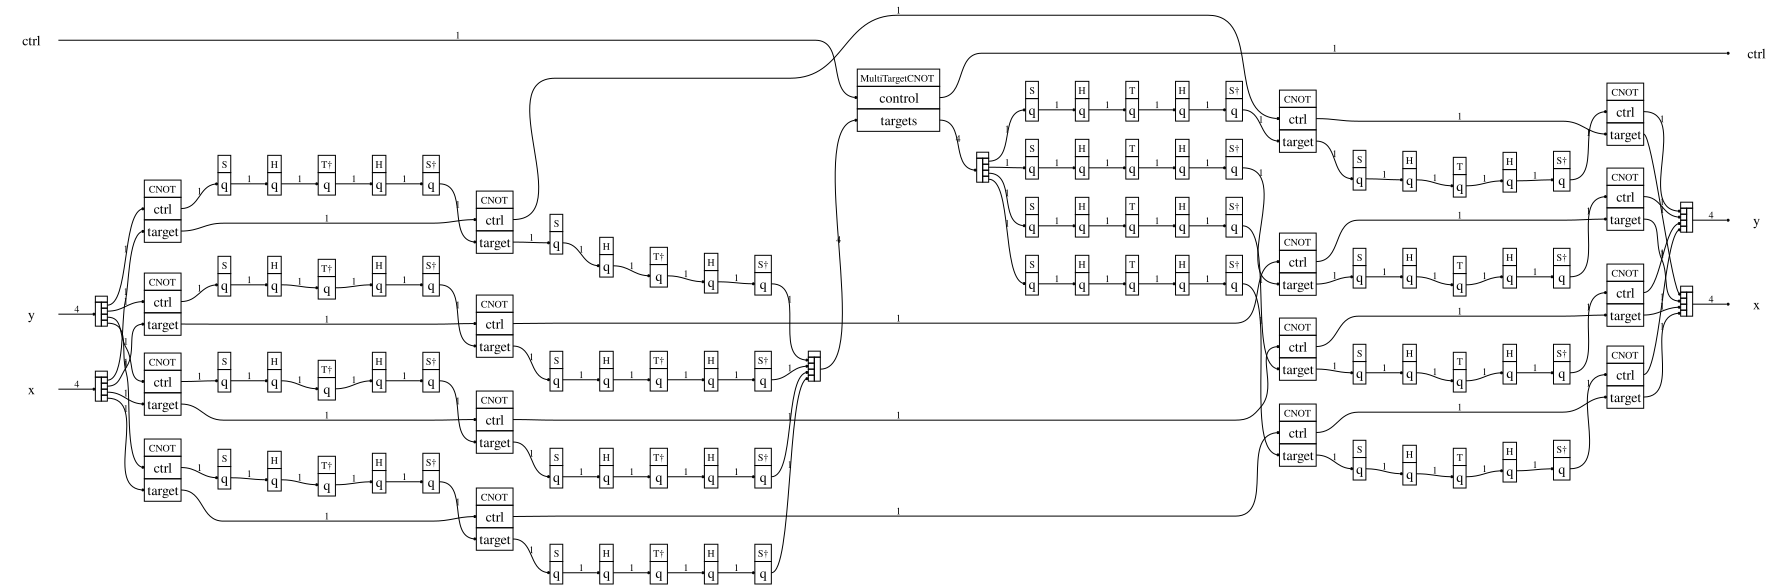

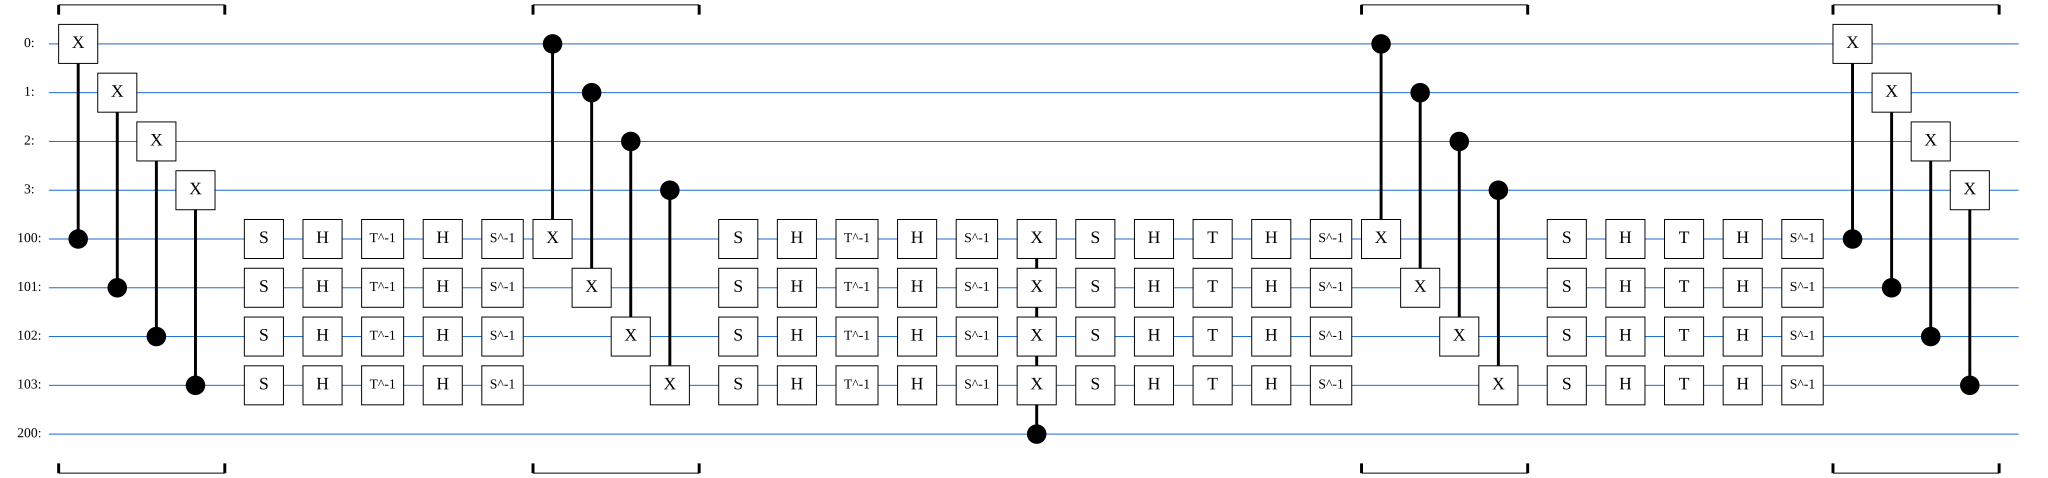

In [ ]:
from cirq.contrib.svg import SVGCircuit
# circuit, output_reg = approx_cswap_small.as_composite_bloq()
show_bloq(approx_cswap_small.decompose_bloq())
print(approx_cswap_small.signature)
# show_bloq(approx_cswap_large.decompose_bloq())
circuit = approx_cswap_small.as_composite_bloq().to_cirq_circuit(
    cirq_quregs= {'x':cirq.LineQubit.range(4), 'y':cirq.LineQubit.range(100,104), 'ctrl':cirq.LineQubit.range(200,201)}
)
(op,) = circuit.all_operations()
swap_decomp_circuit = cirq.Circuit(cirq.decompose_once(op))
SVGCircuit(swap_decomp_circuit)


### Call Graph

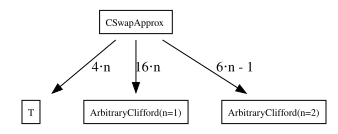

#### Counts totals:
 - `ArbitraryClifford(n=1)`: $\displaystyle 16 n$
 - `ArbitraryClifford(n=2)`: $\displaystyle 6 n - 1$
 - `T`: $\displaystyle 4 n$

In [19]:
from qualtran.resource_counting.generalizers import ignore_split_join
approx_cswap_symb_g, approx_cswap_symb_sigma = approx_cswap_symb.call_graph(max_depth=1, generalizer=ignore_split_join)
show_call_graph(approx_cswap_symb_g)
show_counts_sigma(approx_cswap_symb_sigma)

## `SwapWithZero`
Swaps $|\Psi_0\rangle$ with $|\Psi_x\rangle$ if selection register stores index `x`.

Implements the unitary
$$
U |x\rangle |\Psi_0\rangle |\Psi_1\rangle \dots \Psi_{M-1}\rangle \rightarrow
  |x\rangle |\Psi_x\rangle |\text{Rest of } \Psi\rangle$
$$
Note that the state of $|\text{Rest of } \Psi\rangle$ is allowed to be anything and
should not be depended upon.

Also supports the multidimensional version where $|x\rangle$ can be an n-dimensional index
of the form $|x_1\rangle|x_2\rangle \dots |x_n\rangle$

#### References
 - [Trading T-gates for dirty qubits in state preparation and unitary synthesis](https://arxiv.org/abs/1812.00954). Low, Kliuchnikov, Schaeffer. 2018.


In [20]:
from qualtran.bloqs.swap_network import SwapWithZero

### Example Instances

In [21]:
swz = SwapWithZero(selection_bitsizes=8, target_bitsize=32, n_target_registers=4)

In [22]:
# A small version on four bits.
swz_small = SwapWithZero(selection_bitsizes=3, target_bitsize=2, n_target_registers=2)

In [23]:
swz_multi_dimensional = SwapWithZero(
    selection_bitsizes=(4, 3), target_bitsize=2, n_target_registers=(15, 5)
)

#### Graphical Signature

In [24]:
from qualtran.drawing import show_bloqs
show_bloqs([swz, swz_small, swz_multi_dimensional],
           ['`swz`', '`swz_small`', '`swz_multi_dimensional`'])

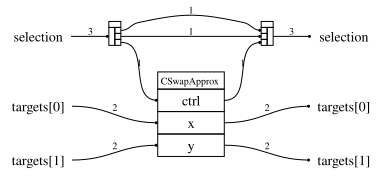

Signature((Register(name='selection', dtype=BQUInt(bitsize=3, iteration_length=2), _shape=(), side=<Side.THRU: 3>), Register(name='targets', dtype=QAny(bitsize=2), _shape=(2,), side=<Side.THRU: 3>)))


IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

In [36]:
show_bloq(swz_small.decompose_bloq())
print(swz_small.signature)
circuit = swz_small.as_composite_bloq().to_cirq_circuit(
    cirq_quregs= {'selection':cirq.LineQubit.range(100,103), 'targets':cirq.GridQubit.rect(2,2)}
)
(op,) = circuit.all_operations()
swap_decomp_circuit = cirq.Circuit(cirq.decompose_once(op))
SVGCircuit(swap_decomp_circuit)

### Call Graph

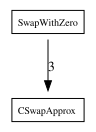

#### Counts totals:
 - `CSwapApprox`: 3

In [25]:
from qualtran.resource_counting.generalizers import ignore_split_join
swz_g, swz_sigma = swz.call_graph(max_depth=1, generalizer=ignore_split_join)
show_call_graph(swz_g)
show_counts_sigma(swz_sigma)

## `MultiplexedCSwap`
Swaps the $l$-th register into an ancilla using unary iteration.

Applies the unitary which performs
$$
    U |l\rangle|\psi_0\rangle\cdots|\psi_l\rangle\cdots|\psi_n\rangle|\mathrm{junk}\rangle
    \rightarrow
    |l\rangle|\psi_0\rangle\cdots|\mathrm{junk}\rangle\cdots|\psi_n\rangle|\psi_l\rangle
$$
through a combination of unary iteration and CSwaps.

The toffoli cost should be $L n_b + L - 2 + n_c$, where $L$ is the
iteration length, $n_b$ is the bitsize of
the registers to swap, and $n_c$ is the number of controls.

#### Parameters
 - `selection_regs`: Indexing `select` signature of type Tuple[`Register`, ...]. It also contains information about the iteration length of each selection register.
 - `target_bitsize`: The size of the registers we want to swap.
 - `control_regs`: Control registers for constructing a controlled version of the gate. 

#### Registers
 - `control_registers`: Control registers
 - `selection_regs`: Indexing `select` signature of type Tuple[`Register`, ...]. It also contains information about the iteration length of each selection register.
 - `target_registers`: Target registers to swap. We swap FROM registers labelled x`i`, where i is an integer and TO a single register called y 

#### References
 - [Fault-Tolerant Quantum Simulations of Chemistry in First Quantization](https://arxiv.org/abs/2105.12767). page 20 paragraph 2.


In [26]:
from qualtran.bloqs.swap_network import MultiplexedCSwap

### Example Instances

In [27]:
from qualtran import BQUInt

selection_bitsize = 3
iteration_length = 5
target_bitsize = 2
multiplexed_cswap = MultiplexedCSwap(
    Register('selection', BQUInt(selection_bitsize, iteration_length)),
    target_bitsize=target_bitsize,
)


#### Graphical Signature

In [28]:
from qualtran.drawing import show_bloqs
show_bloqs([multiplexed_cswap],
           ['`multiplexed_cswap`'])

### Call Graph

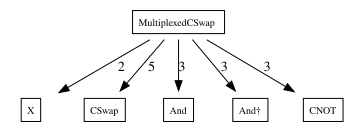

#### Counts totals:
 - `And`: 3
 - `And†`: 3
 - `CNOT`: 3
 - `CSwap`: 5
 - `X`: 2

In [29]:
from qualtran.resource_counting.generalizers import ignore_split_join
multiplexed_cswap_g, multiplexed_cswap_sigma = multiplexed_cswap.call_graph(max_depth=1, generalizer=ignore_split_join)
show_call_graph(multiplexed_cswap_g)
show_counts_sigma(multiplexed_cswap_sigma)

In [30]:
swz_multi_dimensional = SwapWithZero(
    selection_bitsizes=(2, 2), target_bitsize=2, n_target_registers=(3, 4)
)

In [31]:
# A small version on four bits.
selection = sympy.symbols("p q r")
target_bitsize = sympy.Symbol("b")
n_target_registers = sympy.symbols("P Q R")
swz_multi_symbolic = SwapWithZero(
    selection_bitsizes=selection,
    target_bitsize=target_bitsize,
    n_target_registers=n_target_registers,
)